🔬 A/B Test Simulation: Conversion Rate Analysis

📊 STEP 1: State Hypotheses
------------------------------
Null Hypothesis (H₀): There is NO significant difference in conversion rates between Control and Variant groups
Alternative Hypothesis (H₁): There IS a significant difference in conversion rates between Control and Variant groups
Significance level (α): 0.05

📈 STEP 2: Generate Mock Dataset
------------------------------
Dataset shape: (4000, 3)
Control group size: 2000
Variant group size: 2000
Base conversion rate: 12.0%
Expected lift: 3.0%

🔍 STEP 3: Exploratory Data Analysis
------------------------------
Conversion Summary:
         total_users  conversions  conversion_rate
group                                             
Control         2000          236            0.118
Variant         2000          284            0.142

Actual Lift: 2.40%

📊 STEP 4: Statistical Testing (T-Test)
------------------------------
T-statistic: -2.2576
P-value: 0.024024
Significance level (α): 0

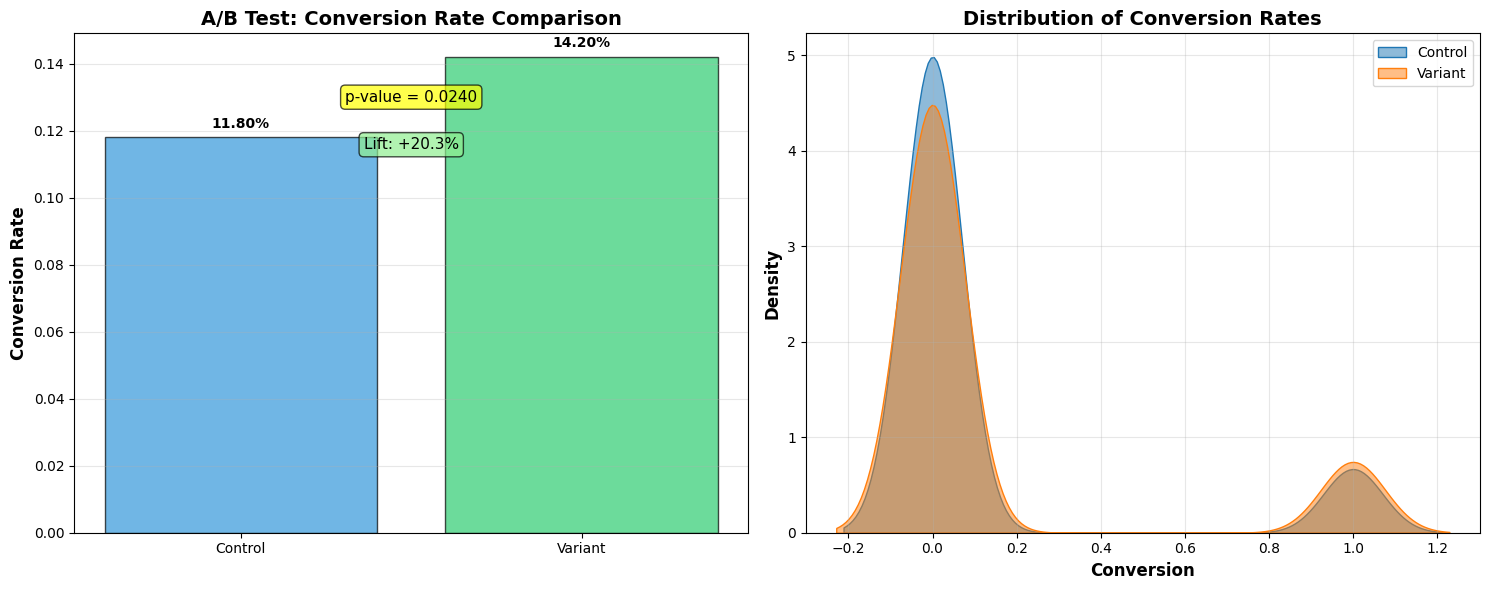


📈 STEP 6: Additional Metrics and Business Impact
------------------------------
Total Conversions - Control: 236
Total Conversions - Variant: 284
Additional Conversions: 48
Additional Revenue (assuming $50/conversion): $2,400.00

⚡ STEP 7: Power Analysis
------------------------------
Effect size: 0.071
Current sample size per group: 2000
Recommended sample size per group for 80% power: 3081

🎯 STEP 8: Conclusion
------------------------------
✅ RECOMMENDATION: IMPLEMENT THE VARIANT
• The Variant group showed a statistically significant improvement
• Conversion rate increased from 11.80% to 14.20%
• This represents a +20.3% lift in conversion rate
• With 2,400.00 in additional revenue demonstrated in this test

📝 Statistical Note:
• P-value: 0.024024 (< 0.05)
• Confidence Level: 95%
• Test Type: Two-sample independent t-test

💾 Results saved to 'ab_test_results.csv'


In [1]:
# A/B Test Simulation and Statistical Analysis
# Simulating Conversion Rates for Control vs Variant Groups

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

print("🔬 A/B Test Simulation: Conversion Rate Analysis")
print("=" * 50)

# Set random seed for reproducibility
np.random.seed(42)

# 1. STATE HYPOTHESES
print("\n📊 STEP 1: State Hypotheses")
print("-" * 30)
print("Null Hypothesis (H₀): There is NO significant difference in conversion rates between Control and Variant groups")
print("Alternative Hypothesis (H₁): There IS a significant difference in conversion rates between Control and Variant groups")
print("Significance level (α): 0.05")

# 2. GENERATE MOCK DATASET
print("\n📈 STEP 2: Generate Mock Dataset")
print("-" * 30)

# Parameters
n_control = 2000      # Number of users in control group
n_variant = 2000      # Number of users in variant group
base_conversion = 0.12  # 12% base conversion rate
lift = 0.03           # 3% lift for variant group (statistically significant difference)

# Generate conversion data
# Control group: base conversion rate
control_conversions = np.random.binomial(1, base_conversion, n_control)
# Variant group: base conversion rate + lift
variant_conversions = np.random.binomial(1, base_conversion + lift, n_variant)

# Create DataFrame
df_control = pd.DataFrame({
    'user_id': range(n_control),
    'group': 'Control',
    'converted': control_conversions
})

df_variant = pd.DataFrame({
    'user_id': range(n_control, n_control + n_variant),
    'group': 'Variant',
    'converted': variant_conversions
})

# Combine datasets
df = pd.concat([df_control, df_variant], ignore_index=True)

print(f"Dataset shape: {df.shape}")
print(f"Control group size: {n_control}")
print(f"Variant group size: {n_variant}")
print(f"Base conversion rate: {base_conversion:.1%}")
print(f"Expected lift: {lift:.1%}")

# 3. EXPLORATORY DATA ANALYSIS
print("\n🔍 STEP 3: Exploratory Data Analysis")
print("-" * 30)

# Summary statistics
conversion_summary = df.groupby('group')['converted'].agg([
    ('total_users', 'count'),
    ('conversions', 'sum'),
    ('conversion_rate', 'mean')
]).round(4)

print("Conversion Summary:")
print(conversion_summary)

# Calculate actual lift
actual_lift = (conversion_summary.loc['Variant', 'conversion_rate'] - 
               conversion_summary.loc['Control', 'conversion_rate'])
print(f"\nActual Lift: {actual_lift:.2%}")

# 4. STATISTICAL TESTING
print("\n📊 STEP 4: Statistical Testing (T-Test)")
print("-" * 30)

# Extract conversion data for each group
control_data = df[df['group'] == 'Control']['converted']
variant_data = df[df['group'] == 'Variant']['converted']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(control_data, variant_data, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level (α): 0.05")

# Determine statistical significance
if p_value < 0.05:
    print("✅ Result: Statistically SIGNIFICANT - Reject the null hypothesis")
    print("💡 Interpretation: There is a statistically significant difference between the groups")
else:
    print("❌ Result: Not statistically significant - Fail to reject the null hypothesis")
    print("💡 Interpretation: No evidence of difference between the groups")

# Calculate confidence intervals
control_mean = control_data.mean()
variant_mean = variant_data.mean()

control_se = control_data.std() / np.sqrt(len(control_data))
variant_se = variant_data.std() / np.sqrt(len(variant_data))

ci_control = stats.norm.interval(0.95, loc=control_mean, scale=control_se)
ci_variant = stats.norm.interval(0.95, loc=variant_mean, scale=variant_se)

print(f"\n📋 Confidence Intervals (95%):")
print(f"Control: {control_mean:.3f} [{ci_control[0]:.3f}, {ci_control[1]:.3f}]")
print(f"Variant: {variant_mean:.3f} [{ci_variant[0]:.3f}, {ci_variant[1]:.3f}]")

# 5. DATA VISUALIZATION
print("\n📊 STEP 5: Data Visualization")
print("-" * 30)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart for conversion rates
groups = ['Control', 'Variant']
conversion_rates = [control_mean, variant_mean]
colors = ['#3498db', '#2ecc71']

bars = ax1.bar(groups, conversion_rates, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Conversion Rate', fontsize=12, fontweight='bold')
ax1.set_title('A/B Test: Conversion Rate Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, rate in zip(bars, conversion_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{rate:.2%}', ha='center', va='bottom', fontweight='bold')

# Add p-value annotation
ax1.text(0.5, max(conversion_rates) * 0.9, f'p-value = {p_value:.4f}', 
         ha='center', va='bottom', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

# Add lift annotation
lift_percentage = ((variant_mean - control_mean) / control_mean) * 100
ax1.text(0.5, max(conversion_rates) * 0.8, f'Lift: {lift_percentage:+.1f}%', 
         ha='center', va='bottom', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

# Distribution plot
sns.kdeplot(control_data, ax=ax2, label='Control', fill=True, alpha=0.5)
sns.kdeplot(variant_data, ax=ax2, label='Variant', fill=True, alpha=0.5)
ax2.set_xlabel('Conversion', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Conversion Rates', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. ADDITIONAL METRICS AND INSIGHTS
print("\n📈 STEP 6: Additional Metrics and Business Impact")
print("-" * 30)

# Calculate additional business metrics
total_conversions_control = control_data.sum()
total_conversions_variant = variant_data.sum()

print(f"Total Conversions - Control: {total_conversions_control}")
print(f"Total Conversions - Variant: {total_conversions_variant}")
print(f"Additional Conversions: {total_conversions_variant - total_conversions_control}")

# Assuming each conversion has a value (e.g., $50)
conversion_value = 50
additional_revenue = (total_conversions_variant - total_conversions_control) * conversion_value
print(f"Additional Revenue (assuming ${conversion_value}/conversion): ${additional_revenue:,.2f}")

# 7. POWER ANALYSIS (Optional)
print("\n⚡ STEP 7: Power Analysis")
print("-" * 30)

# Simplified power calculation
from statsmodels.stats.power import TTestIndPower

# Parameters for power analysis
effect_size = (variant_mean - control_mean) / np.sqrt((control_data.var() + variant_data.var()) / 2)
alpha = 0.05
power = 0.8

# Calculate required sample size
analysis = TTestIndPower()
required_n = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha, ratio=1)

print(f"Effect size: {effect_size:.3f}")
print(f"Current sample size per group: {n_control}")
print(f"Recommended sample size per group for 80% power: {required_n:.0f}")

# 8. CONCLUSION
print("\n🎯 STEP 8: Conclusion")
print("-" * 30)

if p_value < 0.05:
    print("✅ RECOMMENDATION: IMPLEMENT THE VARIANT")
    print(f"• The Variant group showed a statistically significant improvement")
    print(f"• Conversion rate increased from {control_mean:.2%} to {variant_mean:.2%}")
    print(f"• This represents a {lift_percentage:+.1f}% lift in conversion rate")
    print(f"• With {additional_revenue:,.2f} in additional revenue demonstrated in this test")
else:
    print("❌ RECOMMENDATION: KEEP THE CONTROL")
    print("• No statistically significant difference was detected")
    print("• The Variant did not demonstrate clear improvement over Control")

print(f"\n📝 Statistical Note:")
print(f"• P-value: {p_value:.6f} ({'<' if p_value < 0.05 else '>'} 0.05)")
print(f"• Confidence Level: 95%")
print(f"• Test Type: Two-sample independent t-test")

# Save results to CSV
df.to_csv('ab_test_results.csv', index=False)
print(f"\n💾 Results saved to 'ab_test_results.csv'")